## Loan Payback Prediction
Help lenders make better loan approval decisions by predicting risk, explaining why and assessing if a borrower will pay back their loan.

## Dataset Description
The dataset provided for the competition (both train and test) is a direct replica of a real-world scenario. Feature distributions are close to, but not exactly the same, as the original. Feel free to use the original dataset as part of this competition, both to explore differences as well as to see whether incorporating the original in training improves model performance.

Columns include:
- id	                   Unique identifier for each loan record.
- annual_income	           The applicant’s yearly income in monetary units.
- debt_to_income_ratio	   Ratio of total debt payments to income. It indicates the applicant’s financial burden.
- credit_score	           Numerical credit score representing the borrower’s creditworthiness.
- loan_amount	           Total amount of money borrowed by the applicant.
- interest_rate	           Interest rate applied to the loan.
- gender	               Gender of the loan applicant.
- marital_status	       Marital status of the applicant (e.g., single, married).
- education_level	       Highest level of education attained by the applicant.
- employment_status	       Employment situation of the applicant (e.g., employed, unemployed, self-employed).
- loan_purpose	           Reason for taking the loan (e.g., education, home, personal expenses).
- grade_subgrade	       Risk grading assigned to the loan, often used in lending platforms to indicate borrower risk levels.
- loan_paid_back	       Indicates whether the borrower paid back the loan. Typically: 1 = paid back, 0 = not paid back (default).

## Files
- train.csv - the training dataset; loan_paid_back is the binary target.
- test.csv - the test dataset; your objective is to predict probability of the target loan_paid_back for each row.
- sample_submission.csv - a sample submission file in the correct format.

In [1]:
#importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
#loading data
df = pd.read_csv('train.csv', index_col=0)
df.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
id,,,,,,,,,,,,
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [3]:
df.shape

(593994, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 593994 entries, 0 to 593993
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   annual_income         593994 non-null  float64
 1   debt_to_income_ratio  593994 non-null  float64
 2   credit_score          593994 non-null  int64  
 3   loan_amount           593994 non-null  float64
 4   interest_rate         593994 non-null  float64
 5   gender                593994 non-null  object 
 6   marital_status        593994 non-null  object 
 7   education_level       593994 non-null  object 
 8   employment_status     593994 non-null  object 
 9   loan_purpose          593994 non-null  object 
 10  grade_subgrade        593994 non-null  object 
 11  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 58.9+ MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
annual_income,593994.0,48212.202976,26711.942078,6002.430,27934.400,46557.680,60981.320,393381.740
debt_to_income_ratio,593994.0,0.120696,0.068573,0.011,0.072,0.096,0.156,0.627
credit_score,593994.0,680.916009,55.424956,395.000,646.000,682.000,719.000,849.000
loan_amount,593994.0,15020.297629,6926.530568,500.090,10279.620,15000.220,18858.580,48959.950
interest_rate,593994.0,12.356345,2.008959,3.200,10.990,12.370,13.680,20.990
loan_paid_back,593994.0,0.798820,0.400883,0.000,1.000,1.000,1.000,1.000


In [6]:
#checking unique categorical values in gender
df['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [7]:
#checking unique categorical values in marital_status
df['marital_status'].unique()

array(['Single', 'Married', 'Divorced', 'Widowed'], dtype=object)

In [8]:
#checking unique categorical values in education_level
df['education_level'].unique()

array(['High School', "Master's", "Bachelor's", 'PhD', 'Other'],
      dtype=object)

In [9]:
#checking unique categorical values in employment_status
df['employment_status'].unique()

array(['Self-employed', 'Employed', 'Unemployed', 'Retired', 'Student'],
      dtype=object)

In [10]:
#checking unique categorical values in loan_purpose
df['loan_purpose'].unique()

array(['Other', 'Debt consolidation', 'Home', 'Education', 'Vacation',
       'Car', 'Medical', 'Business'], dtype=object)

In [11]:
#checking unique categorical values in grade_subgrade
df['grade_subgrade'].unique()

array(['C3', 'D3', 'C5', 'F1', 'D1', 'D5', 'C2', 'C1', 'F5', 'D4', 'C4',
       'D2', 'E5', 'B1', 'B2', 'F4', 'A4', 'E1', 'F2', 'B4', 'E4', 'B3',
       'E3', 'B5', 'E2', 'F3', 'A5', 'A3', 'A1', 'A2'], dtype=object)

In [12]:
#checking our target varible
df['loan_paid_back'].value_counts()

loan_paid_back
1.0    474494
0.0    119500
Name: count, dtype: int64

In [13]:
#finding percentage of classified loans paid back distribution
total = df['loan_paid_back'].value_counts().sum()
percentage_loan_paid_back = df['loan_paid_back'].value_counts()/total *100

round(percentage_loan_paid_back, 2)

loan_paid_back
1.0    79.88
0.0    20.12
Name: count, dtype: float64

#### Report:
- No null values and dtypes are correct.
- Categorical variables present in dataset.
- annual income and loan amount have large values which can skew our model predictions.

In [14]:
#encoding categorical variables
df_dummies = pd.get_dummies(df, dtype=int)

#setting column titles in a way to get the response variable at the end of the dataframe
column_titles = [col for col in df_dummies.columns if col != 'loan_paid_back'] + ['loan_paid_back']

#reindexing columns in df
df_dummies = df_dummies.reindex(columns=column_titles)
df_dummies.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender_Female,gender_Male,gender_Other,marital_status_Divorced,marital_status_Married,...,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5,loan_paid_back
id,,,,,,,,,,,,,,,,,,,,,
0,29367.99,0.084,736,2528.42,13.67,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.0
1,22108.02,0.166,636,4593.10,12.92,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0.0
2,49566.20,0.097,694,17005.15,9.76,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1.0
3,46858.25,0.065,533,4682.48,16.10,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1.0
4,25496.70,0.053,665,12184.43,10.21,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1.0


In [15]:
#checking high correlations
df_corr = df_dummies.corr()

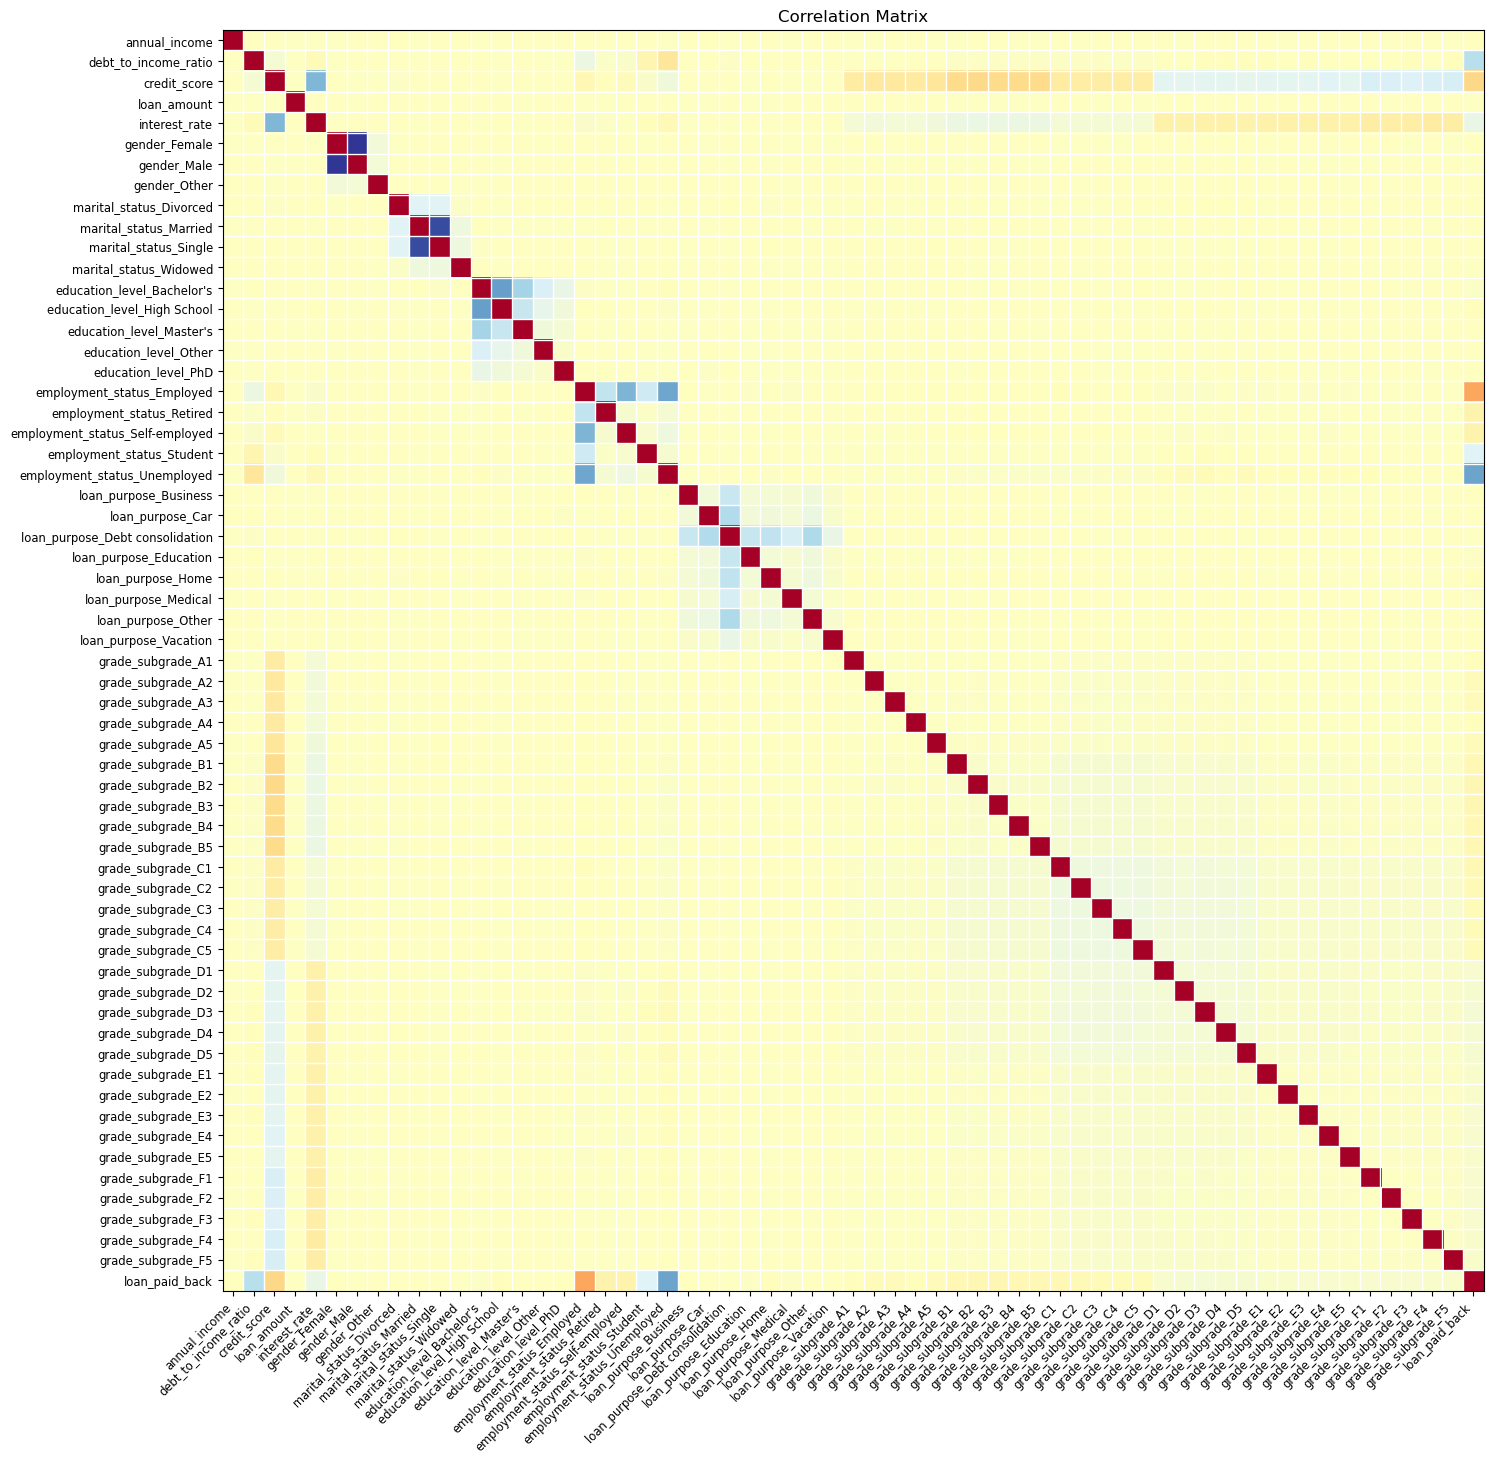

In [16]:
#visualizing correlations
from statsmodels.graphics.correlation import plot_corr

fig = plt.figure(figsize=(15,15))
ax = plt.gca()
plot_corr(df_corr, xnames= df_corr.columns, ax = ax)
plt.show()

Features of interest identified.
- debt to income ratio
- credit score
- interest rate
- employment

In [17]:
#copying df
data = df.copy()
data.head(2)

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
id,,,,,,,,,,,,
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0


In [18]:
#defining a function to preprocess our data
def process_data(df):
    if "loan_paid_back" in df.columns:
        data = df.drop(columns=["loan_paid_back"], axis=1)
    else:
        data = df

    #encoding categorical values
    data_dummies = pd.get_dummies(data, dtype=int)

    #standardizing features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data_dummies)

    return X_scaled

In [19]:
#using function on our train dataset if it works as intended
X = process_data(data)
y = df["loan_paid_back"].values

In [20]:
#spliting dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Training our model

In [21]:
#creating a logistic regression object
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [22]:
#predicting y using the train dataset imported
y_pred = model.predict(X_test)

In [23]:
#creating a dataframe of predicted y and tested y values
prediction_df = pd.DataFrame({"Y_tested": y_test,
              "Y_predicted": y_pred,})

In [24]:
# checking report
report = classification_report(y_test, y_pred, output_dict=True)
train_df_report = pd.DataFrame(report).transpose()

print(train_df_report)

              precision    recall  f1-score        support
0.0            0.860648  0.606617  0.711642   23997.000000
1.0            0.907347  0.975138  0.940021   94802.000000
accuracy       0.900698  0.900698  0.900698       0.900698
macro avg      0.883997  0.790878  0.825832  118799.000000
weighted avg   0.897914  0.900698  0.893890  118799.000000


In [25]:
#checking percentage of predicted values for tuned_1
total_predictions = prediction_df["Y_predicted"].value_counts().sum()

percentage_tuned = prediction_df["Y_predicted"].value_counts()/total_predictions * 100
round(percentage_tuned, 2)

Y_predicted
1.0    85.76
0.0    14.24
Name: count, dtype: float64

## Applying model on the test dataset

In [26]:
#load test dataset
test_df = pd.read_csv("test.csv", index_col=0)
test_df.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
id,,,,,,,,,,,
593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1


In [27]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 254569 entries, 593994 to 848562
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   annual_income         254569 non-null  float64
 1   debt_to_income_ratio  254569 non-null  float64
 2   credit_score          254569 non-null  int64  
 3   loan_amount           254569 non-null  float64
 4   interest_rate         254569 non-null  float64
 5   gender                254569 non-null  object 
 6   marital_status        254569 non-null  object 
 7   education_level       254569 non-null  object 
 8   employment_status     254569 non-null  object 
 9   loan_purpose          254569 non-null  object 
 10  grade_subgrade        254569 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 23.3+ MB


In [28]:
#using test dataset loaded to predict loan paid back
X = process_data(test_df)
y = y[:254569]

In [29]:
#spliting dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
#creating a logistic regression object
lm = LogisticRegression()

lm.fit(X_train, y_train)

LogisticRegression()

In [31]:
#predicting y values
y_pred_testing = lm.predict(X_test)
y_pred_testing

array([1., 1., 1., ..., 1., 1., 1.])

In [32]:
#checking predicted y values from test data against y values from train data
pd.DataFrame({"Y_tested": y_test, "Y_predicted_from_test_data": y_pred_testing})

,Y_tested,Y_predicted_from_test_data
0,1.0,1.0
1,1.0,1.0
2,1.0,1.0
3,1.0,1.0
4,1.0,1.0
...,...,...
50909,1.0,1.0
50910,0.0,1.0
50911,1.0,1.0
50912,1.0,1.0


#### Checking classification reports and accuracy of our model

In [33]:
#checking report for test dataset
report = classification_report(y_test, y_pred_testing, output_dict=True)
test_df_report = pd.DataFrame(report).transpose()

print(test_df_report)

              precision    recall  f1-score       support
0.0            0.000000  0.000000  0.000000  10285.000000
1.0            0.797993  1.000000  0.887648  40629.000000
accuracy       0.797993  0.797993  0.797993      0.797993
macro avg      0.398996  0.500000  0.443824  50914.000000
weighted avg   0.636792  0.797993  0.708337  50914.000000


## Improving the Logistic model

In [34]:
#tuning model with l2 and predicting outcomes
lm_tuned = LogisticRegression(solver="lbfgs")

lm_tuned.fit(X_train, y_train)

# generating predictions from vt model
pred_lm_vt = lm_tuned.predict(X_test)
pred_lm_vt

array([1., 1., 1., ..., 1., 1., 1.])

In [35]:
#checking report for test dataset
report = classification_report(y_test, pred_lm_vt, output_dict=True)
new_report = pd.DataFrame(report).transpose()

print(new_report)

              precision    recall  f1-score       support
0.0            0.000000  0.000000  0.000000  10285.000000
1.0            0.797993  1.000000  0.887648  40629.000000
accuracy       0.797993  0.797993  0.797993      0.797993
macro avg      0.398996  0.500000  0.443824  50914.000000
weighted avg   0.636792  0.797993  0.708337  50914.000000


In [36]:
#fitting the model_vt and predicting outcomes
lm_tuned_1 = LogisticRegression(penalty='l1', solver='liblinear')

lm_tuned_1.fit(X_train, y_train)

# generating predictions from vt model
pred_lm_l2 = lm_tuned_1.predict(X_test)
pred_lm_l2

array([1., 1., 1., ..., 1., 1., 1.])

In [37]:
#checking report for test dataset
report = classification_report(y_test, pred_lm_l2, output_dict=True)
report_l2 = pd.DataFrame(report).transpose()

print(report_l2)

              precision    recall  f1-score       support
0.0            0.000000  0.000000  0.000000  10285.000000
1.0            0.797993  1.000000  0.887648  40629.000000
accuracy       0.797993  0.797993  0.797993      0.797993
macro avg      0.398996  0.500000  0.443824  50914.000000
weighted avg   0.636792  0.797993  0.708337  50914.000000


## Using SVM